In [15]:
from scripts.getQuartets import *
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [16]:
FACTORS = ["0.5", "1.0", "2.0", "4.0", "8.0"]
POLYMORPHISM = ["modhigh", "veryhigh", "mod", "high", "low"]
METHODS = ["ASTRAL", "ASTRAL-H", "MP4"]

In [17]:
def get_data(score_path="./inference_outputs/scores.txt", method=None, has_morph: str = ""):
    print(f"path = {score_path}")
    data = {'score': [], 'polymorphism': [], 'factor': [], 'method': [], 'has_morph': []}
    with open(score_path) as f:
        lines = f.read().split('\n')
        N = len(lines)
        for i in range(0, N - 1, 2):
            filename = lines[i]
            try:
                score = float(lines[i + 1].split()[1])        
            except:
                print(f"FAIL: i={i + 1}, line={lines[i + 1]}")
            if(score < 0):
                print("Negative value: ", filename)
                continue
            data['score'].append(score * 100)
            for p in POLYMORPHISM:
                if p in filename:
                    data['polymorphism'].append(p)
                    break
            for f in FACTORS:
                if f in filename:
                    data['factor'].append(f)
                    break
            data['method'].append(method)
            data['has_morph'].append(has_morph)
            # print(s, score)
    return data


In [18]:

data = {
    'score': [],
    'polymorphism': [],
    'method': [],
    'factor': [],
    'summary': [],
    'has_morph': []
}
hue_ord = []
for f in FACTORS:
    for m in METHODS:
        data_ = get_data(f"./outputs_no_morph/inference_outputs-{f}/{m}/allscores.txt", m, has_morph='No morphological chrs.')
        data['score'] += data_['score']
        data['polymorphism'] += data_['polymorphism']
        data['method'] += [ m for m in data_['method'] ]
        data['factor'] += data_['factor']
        data['has_morph'] += data_['has_morph']
        data['summary'] += [f'{m}-{p}' for m, p in zip(data_['method'], data_['polymorphism'])]

for p in ["low", "mod", "modhigh", "high", "veryhigh"]:
    for m in METHODS:
        hue_ord.append(f'{m}-{p}')

data_nomorph = data

path = ./outputs_no_morph/inference_outputs-0.5/ASTRAL/allscores.txt
path = ./outputs_no_morph/inference_outputs-0.5/ASTRAL-H/allscores.txt
path = ./outputs_no_morph/inference_outputs-0.5/MP4/allscores.txt
path = ./outputs_no_morph/inference_outputs-1.0/ASTRAL/allscores.txt
path = ./outputs_no_morph/inference_outputs-1.0/ASTRAL-H/allscores.txt
path = ./outputs_no_morph/inference_outputs-1.0/MP4/allscores.txt
path = ./outputs_no_morph/inference_outputs-2.0/ASTRAL/allscores.txt
path = ./outputs_no_morph/inference_outputs-2.0/ASTRAL-H/allscores.txt
path = ./outputs_no_morph/inference_outputs-2.0/MP4/allscores.txt
path = ./outputs_no_morph/inference_outputs-4.0/ASTRAL/allscores.txt
path = ./outputs_no_morph/inference_outputs-4.0/ASTRAL-H/allscores.txt
path = ./outputs_no_morph/inference_outputs-4.0/MP4/allscores.txt
path = ./outputs_no_morph/inference_outputs-8.0/ASTRAL/allscores.txt
Negative value:  ./QuartetMethods/example/simulated_data_small-8.0/mod_noborrowing/no-morph/sim_tree32_4.cs

In [19]:

data = {
    'score': [],
    'polymorphism': [],
    'method': [],
    'factor': [],
    'summary': [],
    'has_morph': []
}
hue_ord = []
for f in FACTORS:
    for m in METHODS:
        data_ = get_data(f"./outputs_with_morph/inference_outputs-{f}/{m}/allscores.txt", m, has_morph="With morphological chars.")
        data['score'] += data_['score']
        data['polymorphism'] += data_['polymorphism']
        data['method'] += data_['method']
        data['factor'] += data_['factor']
        data['has_morph'] += data_['has_morph']
        data['summary'] += [f'{m}-{p}' for m, p in zip(data_['method'], data_['polymorphism'])]

for p in POLYMORPHISM:
    for m in METHODS:
        hue_ord.append(f'{m}-{p}')

data_morph = data

path = ./outputs_with_morph/inference_outputs-0.5/ASTRAL/allscores.txt
path = ./outputs_with_morph/inference_outputs-0.5/ASTRAL-H/allscores.txt
path = ./outputs_with_morph/inference_outputs-0.5/MP4/allscores.txt
path = ./outputs_with_morph/inference_outputs-1.0/ASTRAL/allscores.txt
path = ./outputs_with_morph/inference_outputs-1.0/ASTRAL-H/allscores.txt
path = ./outputs_with_morph/inference_outputs-1.0/MP4/allscores.txt
path = ./outputs_with_morph/inference_outputs-2.0/ASTRAL/allscores.txt
path = ./outputs_with_morph/inference_outputs-2.0/ASTRAL-H/allscores.txt
path = ./outputs_with_morph/inference_outputs-2.0/MP4/allscores.txt
path = ./outputs_with_morph/inference_outputs-4.0/ASTRAL/allscores.txt
path = ./outputs_with_morph/inference_outputs-4.0/ASTRAL-H/allscores.txt
path = ./outputs_with_morph/inference_outputs-4.0/MP4/allscores.txt
path = ./outputs_with_morph/inference_outputs-8.0/ASTRAL/allscores.txt
path = ./outputs_with_morph/inference_outputs-8.0/ASTRAL-H/allscores.txt
path = .

In [20]:
def merge_datas(A, B):
    for x, t in A.items():
        B[x] += t
        print(x)
    return B

In [21]:
data = merge_datas(data_morph, data_nomorph)
df = pd.DataFrame(data)
df_morph = pd.DataFrame(data_morph)
df_nomorph = pd.DataFrame(data_nomorph)

score
polymorphism
method
factor
summary
has_morph


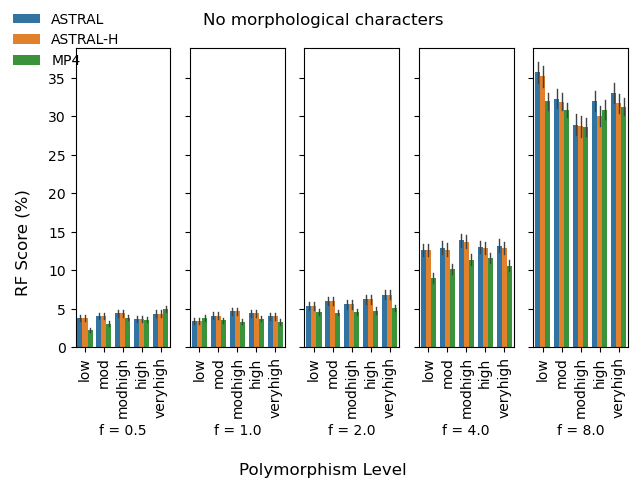

In [38]:
fig, axes = plt.subplots(1, 5, sharey=True)
fig.suptitle("No morphological characters")
fig.supylabel("RF Score (%)")
fig.supxlabel("Polymorphism Level")
loc, labels = plt.xticks()
for f, ax in zip(FACTORS, axes):
    sns.barplot(ax=ax, data=df_nomorph[df_nomorph["factor"] == f], x='polymorphism', y='score', hue='method', errorbar='se', errwidth=1.0)
    ax.get_legend().remove()
    ax.set_xlabel(f"f = {f}")
    ax.set_ylabel("")
    ax.tick_params(axis='x', rotation=90)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig("figs/method-no")

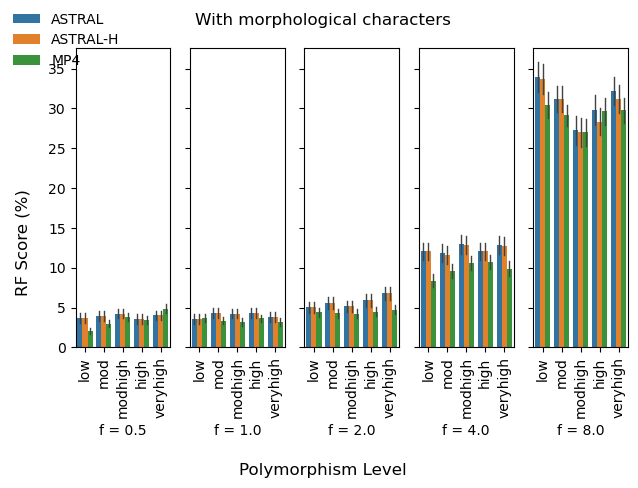

In [37]:
from matplotlib.legend import _get_legend_handles_labels
fig, axes = plt.subplots(1, 5, sharey=True)
fig.suptitle("With morphological characters")
fig.supylabel("RF Score (%)")
fig.supxlabel("Polymorphism Level")
loc, labels = plt.xticks()
for f, ax in zip(FACTORS, axes):
    sns.barplot(ax=ax, data=df_morph[df_morph["factor"] == f], x='polymorphism', y='score', hue='method', errorbar='se', errwidth=1)
    ax.get_legend().remove()
    ax.set_xlabel(f"f = {f}")
    ax.set_ylabel("")
    ax.tick_params(axis='x', rotation=90)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig("figs/method-with")

In [33]:
no_morph_errors = df_nomorph.groupby(["factor", "method", "polymorphism"])["score"].aggregate("mean")
no_morph_errors_np = np.array(no_morph_errors)
morph_errors = df_morph.groupby(["factor", "method", "polymorphism"])["score"].aggregate("mean")
morph_errors_np = np.array(morph_errors)
morph_advantage = no_morph_errors - morph_errors

In [34]:
from matplotlib.legend import _get_legend_handles_labels


def get_graph_for_method(target_method):

    fig, axes = plt.subplots(1, 5, sharey=True)

    fig.suptitle(target_method)
    fig.supylabel("RF Score (%)")
    loc, labels = plt.xticks()
    df_ = df[df["method"] == target_method]
    for f, ax in zip(FACTORS, axes):
        sns.barplot(ax=ax, data=df_[df_["factor"] == f], x='polymorphism', y='score', hue='has_morph', errorbar='se', errwidth=1.0)
        ax.get_legend().remove()
        ax.set_xlabel(f"f = {f}")
        ax.set_ylabel("")
        ax.tick_params(axis='x', rotation=90)
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper left', frameon=False)

    plt.tight_layout()
    plt.savefig(f"figs/morph-{target_method.lower()}")

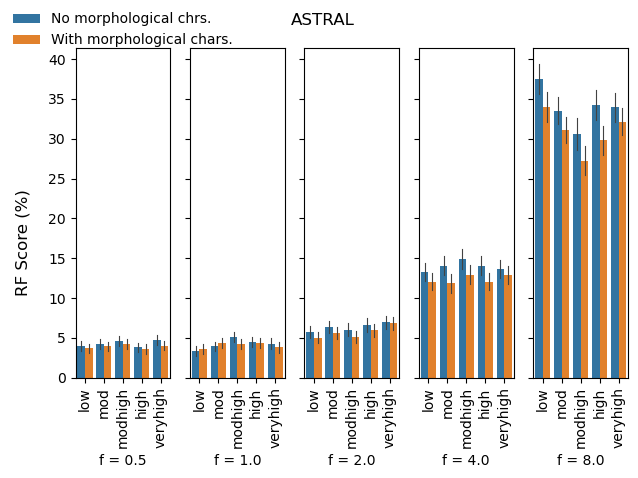

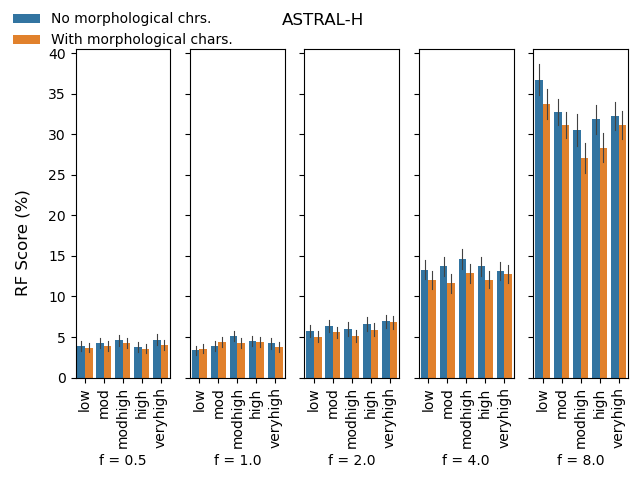

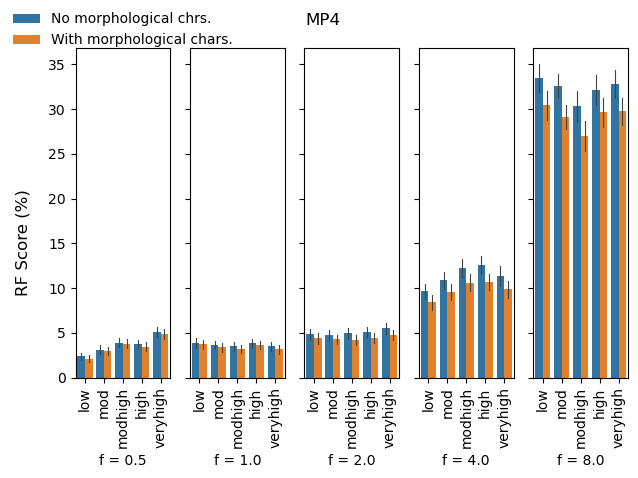

In [31]:
for target_method in METHODS:
    get_graph_for_method(target_method)

In [27]:
df_ = df[df["method"] == "ASTRAL"]
data=df_[df_["factor"] == f]
data

,score,polymorphism,method,factor,summary,has_morph
7680,0.000000,low,ASTRAL,8.0,ASTRAL-low,No morphological chrs.
7681,28.571429,low,ASTRAL,8.0,ASTRAL-low,No morphological chrs.
7682,28.571429,low,ASTRAL,8.0,ASTRAL-low,No morphological chrs.
7683,14.285714,low,ASTRAL,8.0,ASTRAL-low,No morphological chrs.
7684,85.714286,low,ASTRAL,8.0,ASTRAL-low,No morphological chrs.
...,...,...,...,...,...,...
17913,0.000000,veryhigh,ASTRAL,8.0,ASTRAL-veryhigh,With morphological chars.
17914,28.571429,veryhigh,ASTRAL,8.0,ASTRAL-veryhigh,With morphological chars.
17915,28.571429,veryhigh,ASTRAL,8.0,ASTRAL-veryhigh,With morphological chars.
17916,42.857143,veryhigh,ASTRAL,8.0,ASTRAL-veryhigh,With morphological chars.
